IMPORT THE PACKAGES

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

DATA Preprocessing

CNN 

In [ ]:
# Data Preprocessing Function
def preprocess_images(folder_path, image_size=(48, 48)):
    images, labels = [], []
    classes = sorted(os.listdir(folder_path))  # Class names
    class_map = {label: idx for idx, label in enumerate(classes)}

    for label in classes:
        label_folder_path = os.path.join(folder_path, label)
        for img_name in os.listdir(label_folder_path):
            img_path = os.path.join(label_folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, image_size)
                images.append(img)
                labels.append(class_map[label])
    
    images = np.array(images).reshape(-1, image_size[0], image_size[1], 1) / 255.0
    labels = to_categorical(labels, num_classes=len(classes))
    return images, labels, class_map

# Paths to train and test datasets
train_path = 'D:/Emoji-Prediction/archive/train'
test_path = 'D:/Emoji-Prediction/archive/test'

# Load dataset
x_train, y_train, train_class_map = preprocess_images(train_path)
x_test, y_test, test_class_map = preprocess_images(test_path)

# Verify results
print(f"Training data shape: {x_train.shape}, {y_train.shape}")
print(f"Testing data shape: {x_test.shape}, {y_test.shape}")
print(f"Classes: {train_class_map}")


Training data shape: (28709, 48, 48, 1), (28709, 7)
Testing data shape: (7178, 48, 48, 1), (7178, 7)
Classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


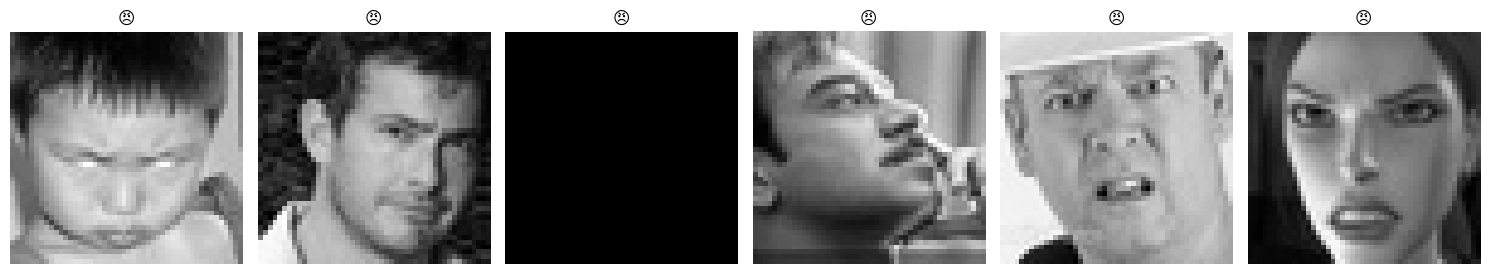

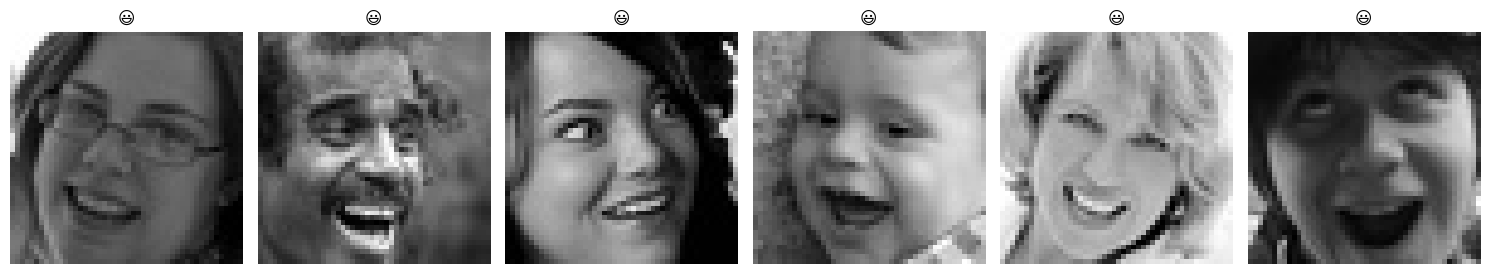

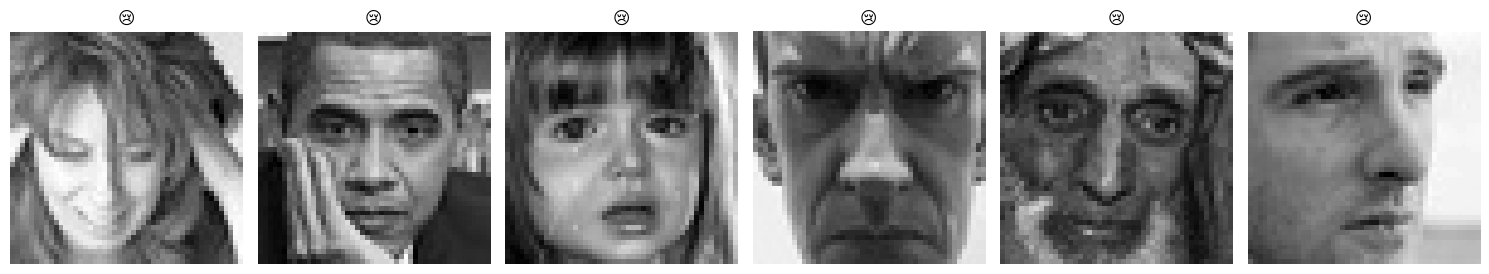

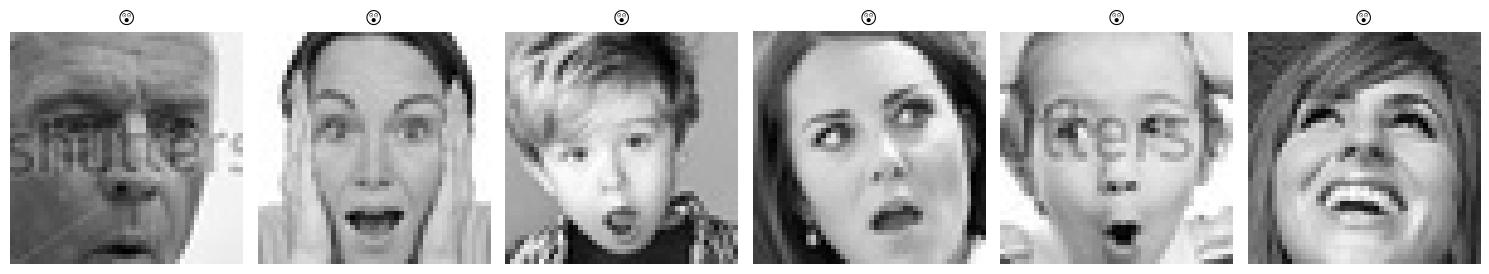

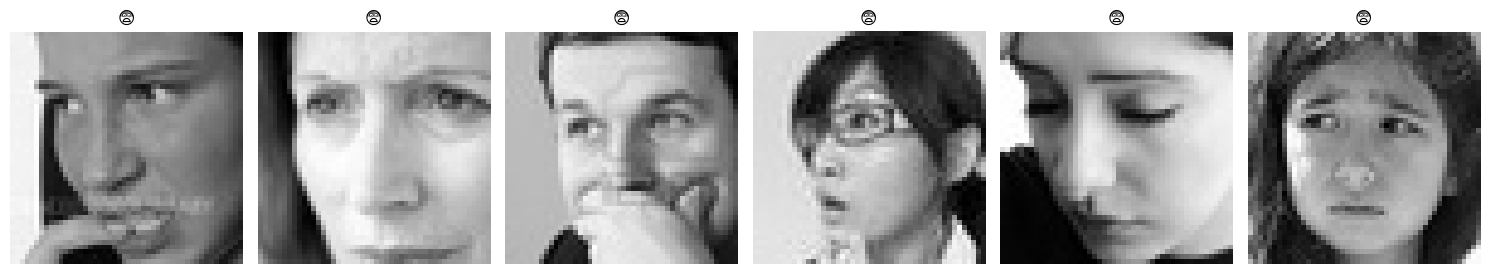

C:\Users\Sri_S\AppData\Local\Temp\ipykernel_16980\3899564117.py:27: UserWarning: Glyph 129326 (\N{FACE WITH OPEN MOUTH VOMITING}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


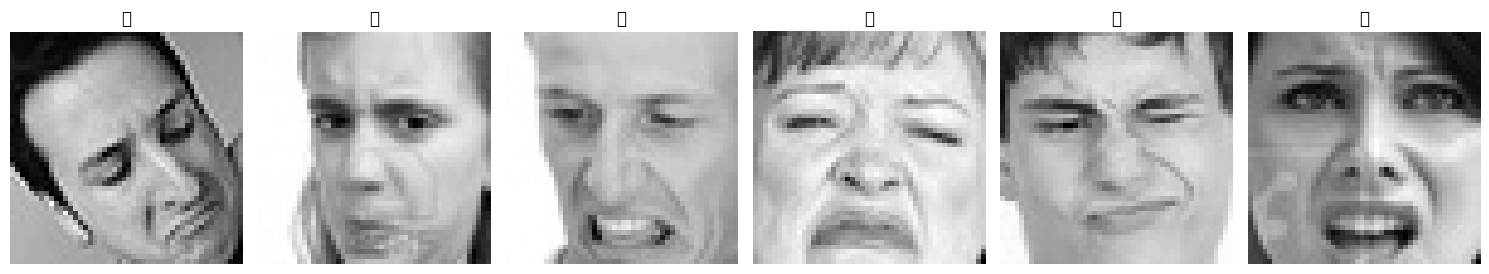

In [8]:
# Correct emoji map
emoji_map = {
    "angry": "😠",    # class 0
    "disgust": "🤮",  # class 1
    "fear": "😨",     # class 2
    "happy": "😃",    # class 3
    "neutral": "😐",  # class 4
    "sad": "😢",      # class 5
    "surprise": "😲"  # class 6
}


def display_images_by_category_with_emojis(category, x_data, y_data, class_map, emoji_map, num_images):
    category_index = class_map[category]
    indices = [i for i, label in enumerate(np.argmax(y_data, axis=1)) if label == category_index]
    
    if not indices:
        print(f"No images found for category: {category}")
        return
    
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i, ax in enumerate(axes):
        if i < len(indices):
            ax.imshow(x_data[indices[i]].reshape(48, 48), cmap='gray')
            ax.set_title(emoji_map.get(category, category))  # Use emoji if available
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Display images for specific categories with emojis
categories = ["angry", "happy", "sad", "surprise", "fear","disgust"]  # Categories to display
for category in categories:
    display_images_by_category_with_emojis(category, x_train, y_train, train_class_map, emoji_map, num_images=6)


New Implementation

In [4]:
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# 1. Data Augmentation

In [10]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(x_train)


2. Improved Model Architecture

In [11]:

# Build Improved Model
base_model = MobileNetV2(input_shape=(48, 48, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze base model weights

model = Sequential([
    Conv2D(3, (3, 3), padding='same', activation='relu', input_shape=(48, 48, 1)),  # Convert grayscale to 3 channels
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


C:\Users\Sri_S\AppData\Local\Temp\ipykernel_16980\2890469946.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(48, 48, 3), include_top=False, weights='imagenet')


# 3. Compile with optimal settings

In [12]:
# Callbacks for best model saving and early stopping
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train Model
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
                    validation_data=(x_test, y_test),
                    epochs=30,
                    callbacks=[checkpoint, early_stop])

# Evaluate Model
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Save Model
model.save('emotion_model_improved.h5')


Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.2113 - loss: 2.0442

449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - accuracy: 0.2114 - loss: 2.0438 - val_accuracy: 0.2857 - val_loss: 1.7507
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2495 - loss: 1.8079

449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.2495 - loss: 1.8079 - val_accuracy: 0.2901 - val_loss: 1.7341
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2618 - loss: 1.7865

449/449 ━━━━━━━━━━━━━━━━━━━━ 30s 67ms/step - accuracy: 0.2618 - loss: 1.7865 - val_accuracy: 0.2953 - val_loss: 1.7164
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2752 - loss: 1.7702

449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.2752 - loss: 1.7702 - val_accuracy: 0.3016 - val_loss: 1.7047
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.2809 - loss: 1.7562

...

449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3127 - loss: 1.7087 - val_accuracy: 0.3264 - val_loss: 1.6585
Epoch 20/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.3124 - loss: 1.7117

449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.3124 - loss: 1.7117 - val_accuracy: 0.3313 - val_loss: 1.6494
Epoch 21/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.3094 - loss: 1.7144 - val_accuracy: 0.3286 - val_loss: 1.6512
Epoch 22/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3078 - loss: 1.7130 - val_accuracy: 0.3271 - val_loss: 1.6535
Epoch 23/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.3118 - loss: 1.7076

449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3118 - loss: 1.7076 - val_accuracy: 0.3321 - val_loss: 1.6541
Epoch 24/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3190 - loss: 1.7020 - val_accuracy: 0.3288 - val_loss: 1.6568
Epoch 25/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3117 - loss: 1.7027 - val_accuracy: 0.3310 - val_loss: 1.6459
Epoch 26/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.3132 - loss: 1.6957

449/449 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.3132 - loss: 1.6957 - val_accuracy: 0.3371 - val_loss: 1.6422
Epoch 27/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.3123 - loss: 1.7033 - val_accuracy: 0.3334 - val_loss: 1.6516
Epoch 28/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 31s 69ms/step - accuracy: 0.3117 - loss: 1.6967 - val_accuracy: 0.3363 - val_loss: 1.6415
Epoch 29/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.3272 - loss: 1.6808 - val_accuracy: 0.3366 - val_loss: 1.6370
Epoch 30/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 32s 71ms/step - accuracy: 0.3218 - loss: 1.6894 - val_accuracy: 0.3370 - val_loss: 1.6385
225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.2363 - loss: 1.8059


Test Accuracy: 33.66%


# 4. Callbacks for training

In [8]:
# callbacks = [
#     EarlyStopping(
#         monitor='val_loss',
#         patience=10,
#         restore_best_weights=True
#     ),
#     ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.2,
#         patience=5,
#         min_lr=1e-6
#     )
# ]


# 5. Train the model with data augmentation

In [9]:
# history = model.fit(
#     datagen.flow(x_train, y_train, batch_size=128),
#     validation_data=(x_test, y_test),
#     epochs=2,
#     callbacks=callbacksA
# )

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Build the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(48, 48, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.0),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.0),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Flatten(),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.0),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,255 (1.36 MB)

 Trainable params: 356,551 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [14]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=64)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.3647 - loss: 1.7326 - val_accuracy: 0.3462 - val_loss: 1.6396
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.5334 - loss: 1.2448 - val_accuracy: 0.4857 - val_loss: 1.3433
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 27s 60ms/step - accuracy: 0.5875 - loss: 1.1016 - val_accuracy: 0.5237 - val_loss: 1.2850
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.6494 - loss: 0.9506 - val_accuracy: 0.5357 - val_loss: 1.2975
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.7043 - loss: 0.8084 - val_accuracy: 0.5213 - val_loss: 1.3547
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.7652 - loss: 0.6613 - val_accuracy: 0.5361 - val_loss: 1.4174
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8203 - loss: 0.5204 - val_accuracy: 0.5584 - val_loss: 1.4397
Epoch 8/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8677 - loss: 0.3887 - 

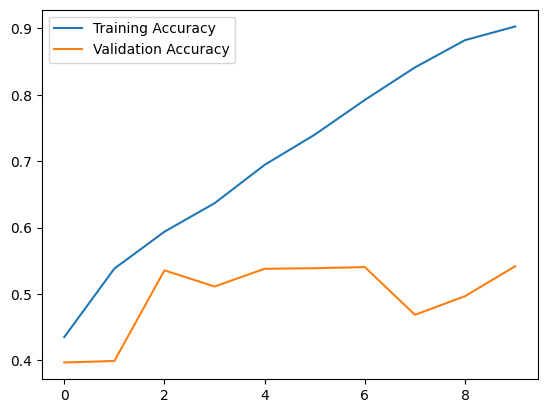

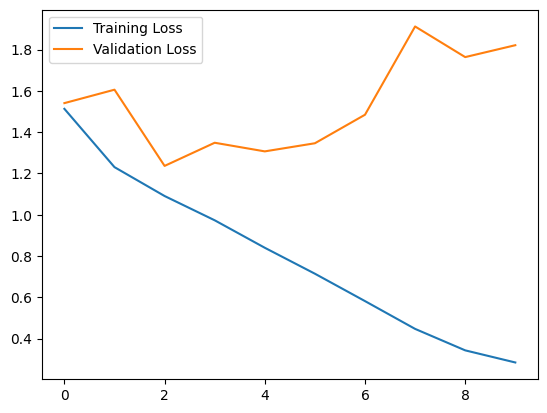

In [19]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [20]:
loss, accuracy = model.evaluate(x_test, y_test, batch_size=64)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5075 - loss: 1.9604
Test Loss: 1.8215581178665161
Test Accuracy: 0.5417943596839905


In [21]:
# Get predictions
predictions = model.predict(x_test)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Calculate accuracy
from sklearn.metrics import accuracy_score
manual_accuracy = accuracy_score(true_classes, predicted_classes)

print(f"Calculated Accuracy: {manual_accuracy}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step
Calculated Accuracy: 0.5417943716912789


In [22]:
class_map = list(train_class_map.keys()) 

In [23]:
# Save the trained model
model.save('emotion_model.h5')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


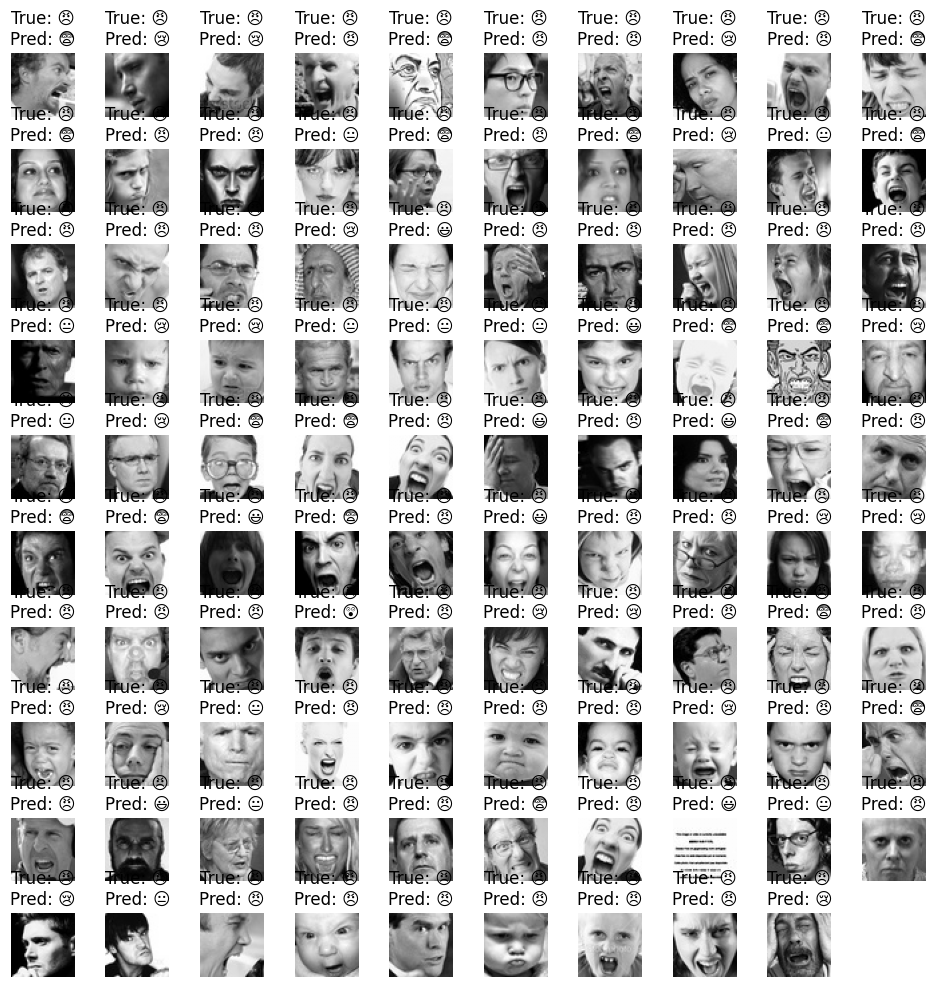

In [24]:
start_index = 1  # Change this to the desired starting index
end_index = 100    # Change this to the desired ending index
indices = np.arange(start_index, end_index)  # Generate the range of indices
num_samples = len(indices)

# Select the samples from the test set
sample_images = x_test[indices]
true_labels = [class_map[np.argmax(y_test[i])] for i in indices]
predictions = model.predict(sample_images.reshape(num_samples, 48, 48, 1))
predicted_labels = [class_map[np.argmax(pred)] for pred in predictions]

# Plot the images in a grid
grid_size = int(np.ceil(np.sqrt(num_samples)))  # Determine grid size (square)
fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
fig.subplots_adjust(hspace=0.5)
for i, ax in enumerate(axes.flat):
    if i < num_samples:
        true_label = emoji_map.get(true_labels[i], true_labels[i])  # Replace with emoji
        predicted_label = emoji_map.get(predicted_labels[i], predicted_labels[i])  # Replace with emoji
        ax.imshow(sample_images[i].reshape(48, 48), cmap='gray')
        ax.set_title(f"True: {true_label}\nPred: {predicted_label}")
        ax.axis('off')
    else:
        ax.axis('off')  # Hide unused subplots

plt.show()

In [25]:
# Count the number of correctly predicted labels
correct_predictions = sum([true_labels[i] == predicted_labels[i] for i in range(num_samples)])
print(f"Number of correctly predicted samples: {correct_predictions}")
print(f"Accuracy on the selected samples: {correct_predictions / num_samples:.2%}")


Number of correctly predicted samples: 44
Accuracy on the selected samples: 44.44%
